In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import xarray as xr
import cartopy.crs as ccrs

In [28]:
ds = xr.open_dataset('GEOS-CF_AirQuality_20180101_0030z.nc4')

In [29]:
ds

<xarray.Dataset> Size: 21MB
Dimensions:        (time: 1, lev: 1, lat: 721, lon: 1440)
Coordinates:
  * time           (time) datetime64[ns] 8B 2018-01-01T00:30:00
  * lev            (lev) float64 8B 72.0
  * lat            (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon            (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    CO             (time, lev, lat, lon) float32 4MB ...
    NO2            (time, lev, lat, lon) float32 4MB ...
    O3             (time, lev, lat, lon) float32 4MB ...
    PM25_RH35_GCC  (time, lev, lat, lon) float32 4MB ...
    SO2            (time, lev, lat, lon) float32 4MB ...
Attributes: (12/28)
    Contact:               http://gmao.gsfc.nasa.gov
    History:               Original file generated: Mon Dec 24 13:37:28 2018 GMT
    Source:                cak_Icarus-1_0_GCCv12-00-01_v1_010 experiment_id: ...
    Conventions:           CF-1
    Title:                 GEOS CF (Composition Forecast)
    Institution:           NASA Global Modeling and Assimilation Office
    ...                    ...
    DataResolution:        0.25 x 0.25
    LongName:              GEOS CF 2d time-averaged air quality concentration...
    ShortName:             CF01Raqc_1hrT_g1440x721_V1
    Comment:               GMAO filename: c360_GEOS-CF.chm_tavg_1hr_g1440x721...
    Filename:              GEOS-CF.v01.rpl.aqc_tavg_1hr_g1440x721_v1.20180101...
    GranuleID:             GEOS-CF.v01.rpl.aqc_tavg_1hr_g1440x721_v1.20180101...

In [41]:
O3 = ds.O3
O3_ppb = O3 * 1e9
O3_ppb.attrs["units"] = "ppb"

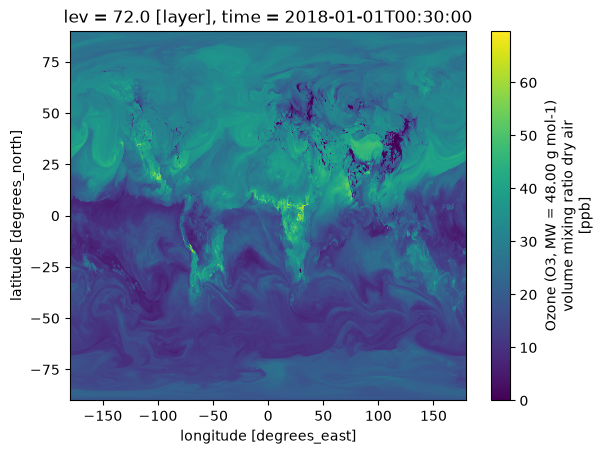

In [42]:
O3_ppb.plot()

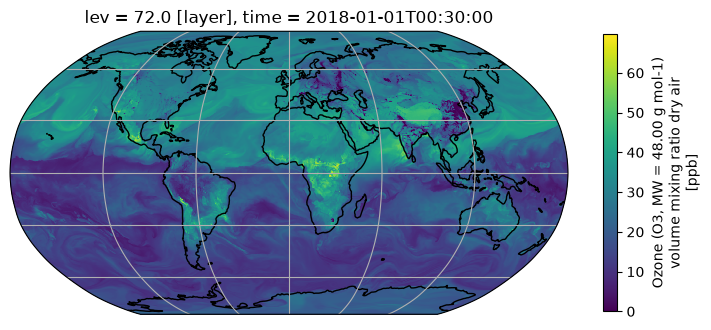

In [43]:
fig = plt.figure(figsize=(9,6))
ax = plt.axes(projection=ccrs.Robinson())
O3_ppb.plot(ax=ax, transform=ccrs.PlateCarree(), 
        cbar_kwargs={'shrink': 0.6})
ax.coastlines()
ax.gridlines()

In [51]:
O3_ppb.sel(lat=[22.62], lon=[114.07], method="nearest").item()

3.507011651992798

Data for Shenzhen

In [52]:
O3_ppb.sel(lat=[34.0522], lon=[-118.2434], method="nearest").item()

45.401973724365234

e. Data for Los Angeles

In [53]:
O3_ppb.sel(lat=[19.8968], lon=[155.5828], method="nearest").item()

26.280759811401367

f. Data for Hawaii

In [61]:
max = O3_ppb.argmax(dim=["lat", "lon"])

In [64]:
max_value = O3_ppb.isel(max)
print ('b.')
print (max_value.lat.item())
print (max_value.lon.item())
print (max_value.item())

b.
34.5
-118.75
69.73278045654297


a. Ozone is qualitatively high for high altitude places where mountains and high land are located. Also relatively high for oceans where more boats are traveling around. 

In [65]:
min = O3_ppb.argmin(dim=["lat", "lon"])
min_value = O3_ppb.isel(min)
print ('d.')
print (min_value.lat.item())
print (min_value.lon.item())
print (min_value.item())

d.
53.0
73.25
0.0


In [ ]:
c. Ozone is qualitatively low around the southern hemisphere ocean where less human activity is there, also low at places with huge amount of population for exmaple east china and center europe. 